In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import pickle
import json

# Load cleaned data
df = pd.read_csv('dataset/cleaned_data.csv')

# Use attack_cat as label (real attack types!)
X = df.drop(['label', 'attack_cat'], axis=1, errors='ignore')
y_cat = df['attack_cat']  # This has real attack names

print("Attack categories:\n", y_cat.value_counts())

Attack categories:
 attack_cat
6    93000
5    58871
3    44525
4    24246
2    16353
7    13987
0     2677
1     2329
8     1511
9      174
Name: count, dtype: int64


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load cleaned data
df = pd.read_csv('dataset/cleaned_data.csv')

# Features and label
X = df.drop(['label', 'attack_cat'], axis=1, errors='ignore')
y = df['label']

print("✅ Data loaded!")
print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

✅ Data loaded!
X shape: (257673, 42)
y distribution:
 label
1    164673
0     93000
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("✅ Split done!")
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

✅ Split done!
Training size: (206138, 42)
Testing size: (51535, 42)


In [6]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Build ensemble
model = VotingClassifier(estimators=[
    ('xgb', XGBClassifier(n_estimators=100, eval_metric='logloss')),
    ('lgbm', LGBMClassifier(n_estimators=100, verbose=-1)),
    ('rf', RandomForestClassifier(n_estimators=100))
], voting='soft')

print("⏳ Training model... this may take 3-5 minutes...")
model.fit(X_train, y_train)
print("✅ Training done!")

⏳ Training model... this may take 3-5 minutes...
✅ Training done!


✅ Model Accuracy: 95.23 %

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.94      0.93     18613
           1       0.97      0.96      0.96     32922

    accuracy                           0.95     51535
   macro avg       0.95      0.95      0.95     51535
weighted avg       0.95      0.95      0.95     51535



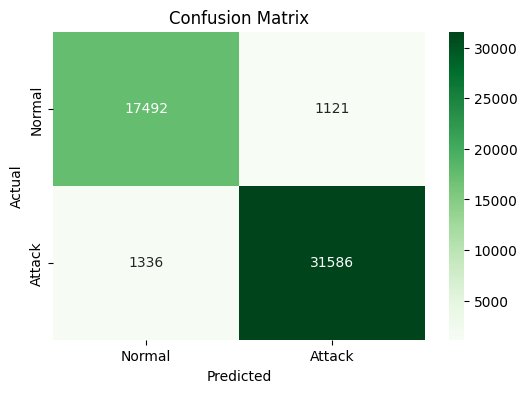

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print("✅ Model Accuracy:", round((y_pred == y_test).mean() * 100, 2), "%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [13]:
import pickle

with open('model/threat_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save column names for later use
import json
with open('model/feature_columns.json', 'w') as f:
    json.dump(list(X.columns), f)

print("✅ Model saved to model/threat_model.pkl!")
print("✅ Features saved to model/feature_columns.json!")

✅ Model saved to model/threat_model.pkl!
✅ Features saved to model/feature_columns.json!


In [14]:
# See original attack names before encoding
df_original = pd.read_csv('dataset/Training and Testing Sets/UNSW_NB15_training-set.csv')
print("Real attack names:\n", df_original['attack_cat'].value_counts())

Real attack names:
 attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pickle
import json

# Load cleaned data
df = pd.read_csv('dataset/cleaned_data.csv')

# Get original attack names
df_orig_train = pd.read_csv('dataset/Training and Testing Sets/UNSW_NB15_training-set.csv')
df_orig_test  = pd.read_csv('dataset/Training and Testing Sets/UNSW_NB15_testing-set.csv')
df_orig = pd.concat([df_orig_train, df_orig_test], ignore_index=True)
df_orig.drop_duplicates(inplace=True)
df_orig.dropna(inplace=True)

# Encode attack names properly
le = LabelEncoder()
le.fit(df_orig['attack_cat'])

# Save label encoder
with open('model/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save mapping
mapping = dict(zip(range(len(le.classes_)), le.classes_))
with open('model/attack_mapping.json', 'w') as f:
    json.dump(mapping, f)

print("✅ Attack mapping saved!")
print("Mapping:", mapping)

✅ Attack mapping saved!
Mapping: {0: 'Analysis', 1: 'Backdoor', 2: 'DoS', 3: 'Exploits', 4: 'Fuzzers', 5: 'Generic', 6: 'Normal', 7: 'Reconnaissance', 8: 'Shellcode', 9: 'Worms'}


In [10]:
# Features and attack category label
X = df.drop(['label', 'attack_cat'], axis=1, errors='ignore')
y = df['attack_cat']  # numbers 0-9

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train ensemble
model_cat = VotingClassifier(estimators=[
    ('xgb',  XGBClassifier(n_estimators=100, eval_metric='mlogloss', use_label_encoder=False)),
    ('lgbm', LGBMClassifier(n_estimators=100, verbose=-1)),
    ('rf',   RandomForestClassifier(n_estimators=100))
], voting='soft')

print("⏳ Training... please wait 3-5 mins...")
model_cat.fit(X_train, y_train)
print("✅ Done!")

# Evaluate
y_pred = model_cat.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

⏳ Training... please wait 3-5 mins...


/home/dipika/Desktop/threat-detection/venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [18:34:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Done!
                precision    recall  f1-score   support

      Analysis       0.61      0.14      0.23       519
      Backdoor       0.64      0.10      0.17       468
           DoS       0.38      0.18      0.24      3292
      Exploits       0.64      0.86      0.73      9080
       Fuzzers       0.71      0.62      0.66      4831
       Generic       1.00      0.98      0.99     11537
        Normal       0.92      0.95      0.93     18613
Reconnaissance       0.91      0.76      0.83      2852
     Shellcode       0.68      0.69      0.68       309
         Worms       0.50      0.32      0.39        34

      accuracy                           0.83     51535
     macro avg       0.70      0.56      0.59     51535
  weighted avg       0.83      0.83      0.82     51535



In [16]:
with open('model/threat_model_cat.pkl', 'wb') as f:
    pickle.dump(model_cat, f)

print("✅ Category model saved!")

✅ Category model saved!


In [17]:
from sklearn.utils import resample
import pandas as pd

# Balance the dataset
df_balanced = pd.DataFrame()
min_samples = 1500  # use same amount for each class

for cat in df['attack_cat'].unique():
    df_cat = df[df['attack_cat'] == cat]
    if len(df_cat) >= min_samples:
        df_cat = resample(df_cat, n_samples=min_samples, random_state=42)
    df_balanced = pd.concat([df_balanced, df_cat])

print("Balanced distribution:\n", df_balanced['attack_cat'].value_counts())

# Retrain with balanced data
X_bal = df_balanced.drop(['label', 'attack_cat'], axis=1, errors='ignore')
y_bal = df_balanced['attack_cat']

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42)

model_bal = VotingClassifier(estimators=[
    ('xgb',  XGBClassifier(n_estimators=100, eval_metric='mlogloss', use_label_encoder=False)),
    ('lgbm', LGBMClassifier(n_estimators=100, verbose=-1)),
    ('rf',   RandomForestClassifier(n_estimators=100))
], voting='soft')

print("⏳ Training balanced model...")
model_bal.fit(X_train, y_train)
print("✅ Done!")

# Evaluate
y_pred = model_bal.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Save
with open('model/threat_model_cat.pkl', 'wb') as f:
    pickle.dump(model_bal, f)
print("✅ Balanced model saved!")

Balanced distribution:
 attack_cat
6    1500
1    1500
0    1500
4    1500
8    1500
7    1500
3    1500
2    1500
5    1500
9     174
Name: count, dtype: int64
⏳ Training balanced model...


/home/dipika/Desktop/threat-detection/venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [18:36:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Done!
                precision    recall  f1-score   support

      Analysis       0.42      0.52      0.47       301
      Backdoor       0.39      0.45      0.42       288
           DoS       0.37      0.34      0.35       289
      Exploits       0.66      0.54      0.59       316
       Fuzzers       0.74      0.78      0.76       284
       Generic       0.99      0.98      0.99       288
        Normal       0.92      0.79      0.85       317
Reconnaissance       0.88      0.84      0.86       312
     Shellcode       0.93      0.99      0.96       306
         Worms       0.91      0.94      0.93        34

      accuracy                           0.70      2735
     macro avg       0.72      0.72      0.72      2735
  weighted avg       0.71      0.70      0.70      2735

✅ Balanced model saved!
